# Heart Disease Prediction 

## Competition Strategy
1. **Comprehensive EDA**
2. **Feature Engineering**
3. **Model Diversity**
4. **Robust Validation**
5. **Intelligent Ensembling**

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Machine learning
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE

# Gradient Boosting
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# Hyperparameter Optimization
import optuna
from optuna.samplers import TPESampler

# Statistical tests
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

# Visualization settings
plt.style.use("dark_background")
sns.set_palette('husl')
pd.set_option("display.max_columns", None)

## Data Loading and Initial Inspection

In [2]:
# Load Datasets

sample_submission = pd.read_csv("/kaggle/input/playground-series-s6e2/sample_submission.csv")

test = pd.read_csv("/kaggle/input/playground-series-s6e2/test.csv")

train = pd.read_csv("/kaggle/input/playground-series-s6e2/train.csv")

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"\nTarget distribution:")
print(train["Heart Disease"].value_counts(normalize = True))

# Display few rows

train.head()

Train shape: (630000, 15)
Test shape: (270000, 14)

Target distribution:
Heart Disease
Absence     0.55166
Presence    0.44834
Name: proportion, dtype: float64


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [3]:
# Data Info

print("-"*50)
print("Training Data Information")
print("-"*50)
print(train.info())

print("\n" + "-"*50)

print("Statistical Summary")
print("-"*50)
print(train.describe())

print("\n" + "-"*50)

# Checking for missing values

print("Missing values")
print("-"*50)

missing = train.isnull().sum()
print(missing[missing > 0]) 

if missing.sum() > 0:
    print(missing)
else: 
    print("No missing values found")

--------------------------------------------------
Training Data Information
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null 

## Exploratory Data Analysis (EDA)

### Target Variable Analysis

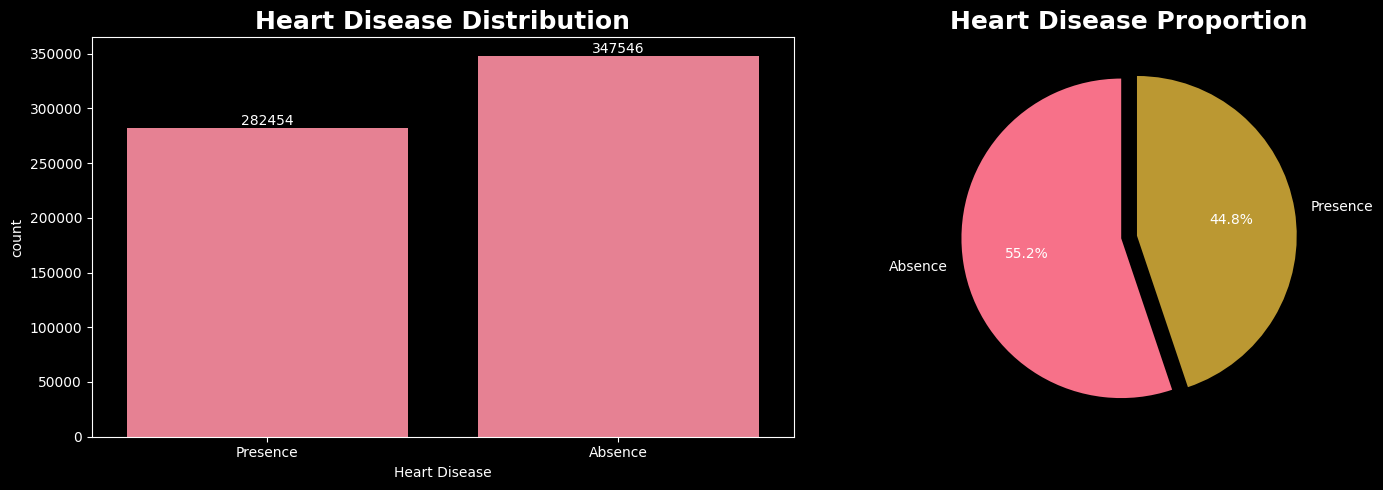

Class Balance: 55.17% Absence, 44.83% Presence


In [4]:
# Encode target for analysis

train["target"] = (train["Heart Disease"] == "Presence").astype(int)

fig, axes = plt.subplots(1, 2, figsize = (15, 5))

# Count plot

sns.countplot(data = train, x = "Heart Disease", ax = axes[0])

axes[0].set_title(
    "Heart Disease Distribution",
    fontsize = 18, 
    fontweight = "bold"
)

for container in axes[0].containers:
    axes[0].bar_label(container)

# Pie chart

target_counts = train["target"].value_counts()

axes[1].pie(
    target_counts, 
    labels = ["Absence", "Presence"], 
    autopct = "%1.1f%%", 
    startangle = 90, 
    explode = (0.05, 0.05)
)
axes[1].set_title(
    "Heart Disease Proportion",
    fontsize = 18,
    fontweight = "bold"
)

plt.tight_layout()
plt.show()

print(f"Class Balance: {target_counts[0]/len(train) * 100:.2f}% Absence, {target_counts[1]/len(train) * 100:0.2f}% Presence")

# Feature Analysis - Numerical Features


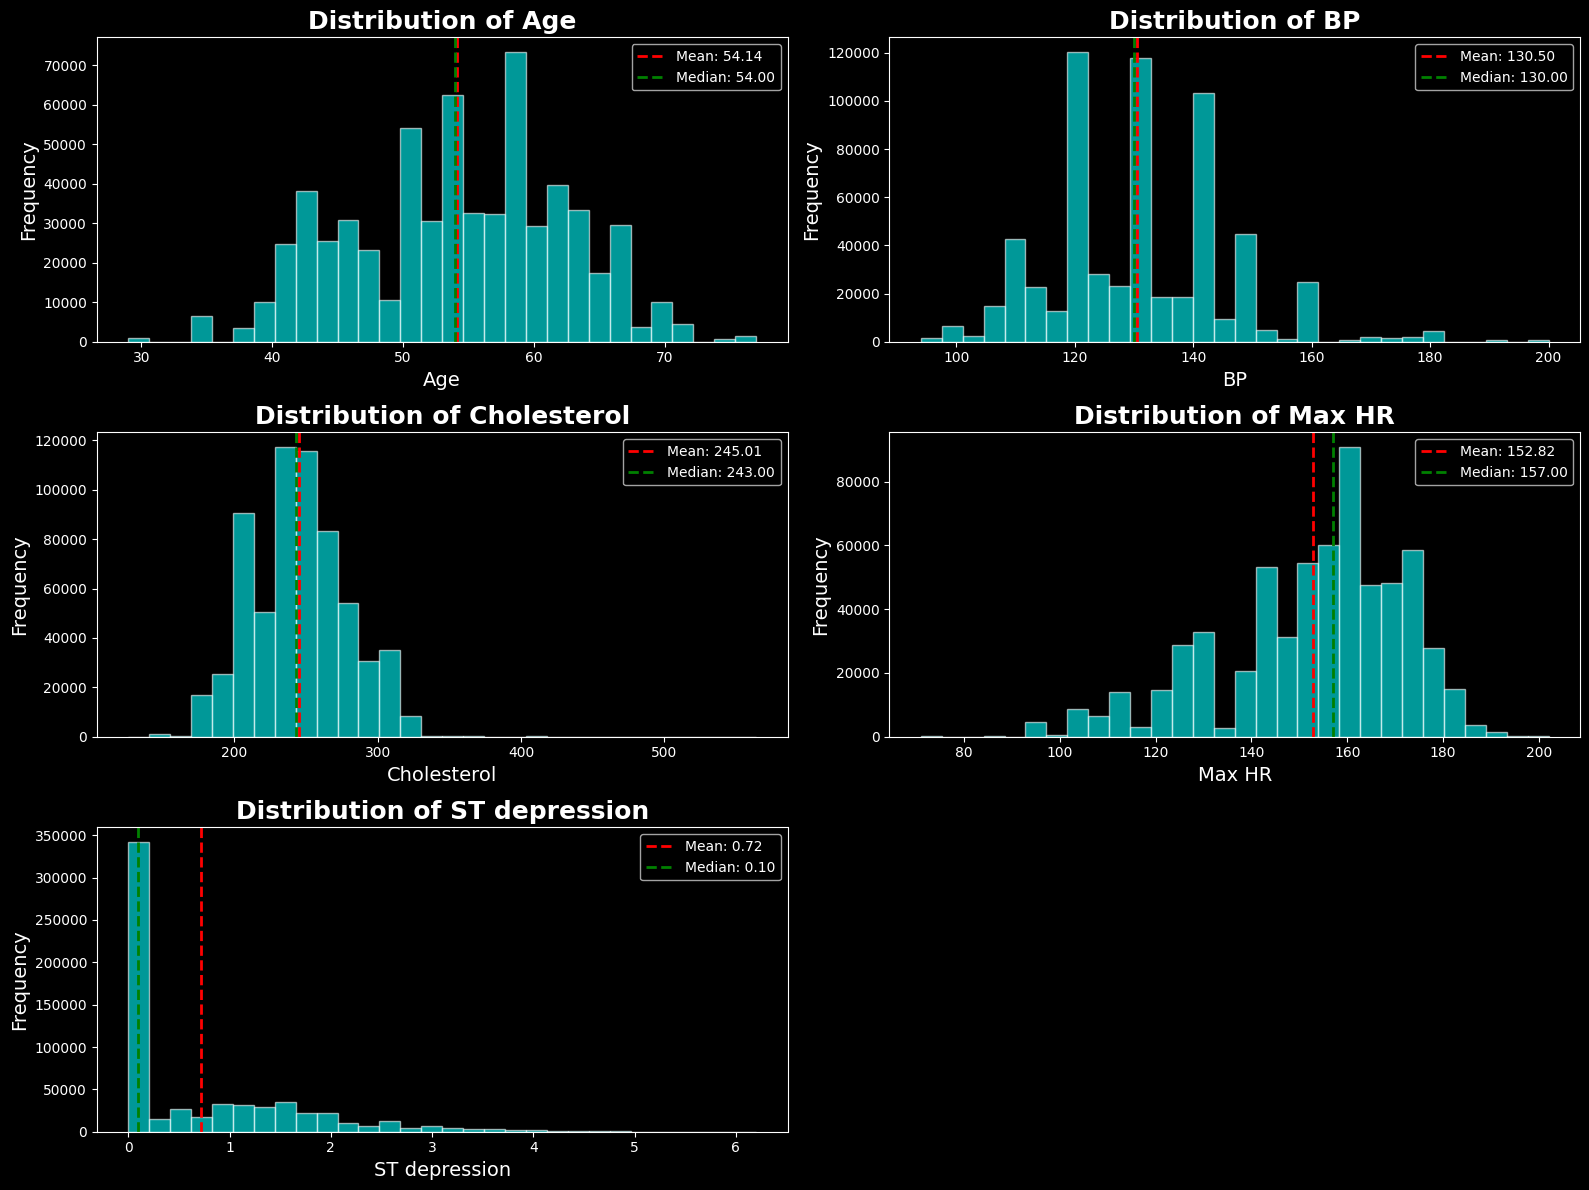

In [5]:
# Define Feature groups
numerical_features = [
    "Age", 
    "BP", 
    "Cholesterol", 
    "Max HR", 
    "ST depression"
]

categorical_features = [
    "Sex", 
    "Chest pain type", 
    "FBS over 120", 
    "EKG results",
    "Exercise angina", 
    "Slope of ST", 
    "Number of vessels fluro", 
    "Thallium"
]

# Distribution of numerical features

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, col in enumerate(numerical_features):
    
    # Histogram with KDE

    axes[idx].hist(train[col], bins = 30, alpha = 0.6, color = "cyan", edgecolor = "white")
    axes[idx].set_title(f"Distribution of {col}", fontsize = 18, fontweight = "bold")
    axes[idx].set_xlabel(col, fontsize = 14)
    axes[idx].set_ylabel("Frequency", fontsize = 14)
    
    # Add mean and median lines

    axes[idx].axvline(
        train[col].mean(), 
        color = "red", 
        linestyle = "--", 
        linewidth = 2, 
        label = f"Mean: {train[col].mean():.2f}"
    )
    
    axes[idx].axvline(
        train[col].median(), 
        color = "green",
        linestyle = "--",
        linewidth = 2,
        label = f"Median: {train[col].median():.2f}"
    )
    axes[idx].legend()

# Remove empty subplot

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

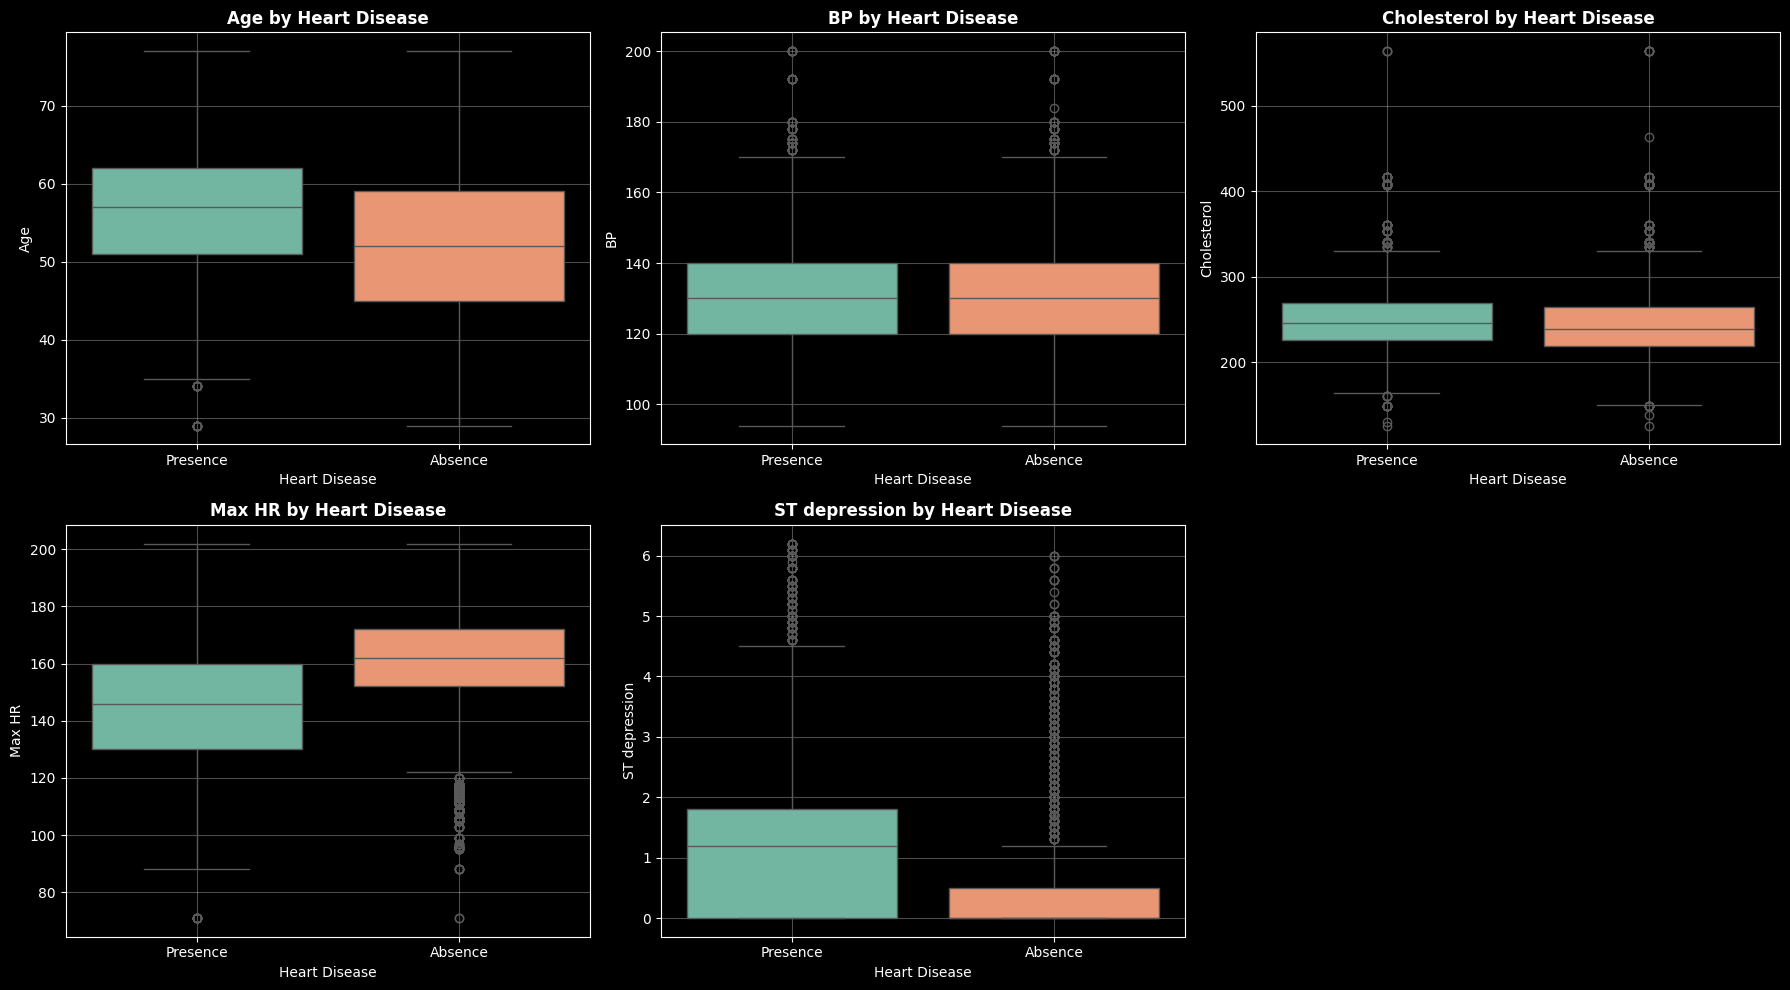

In [6]:
# Box Plots by target

fig, axes = plt.subplots(2, 3, figsize = (18, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_features):
    sns.boxplot(data = train, x = "Heart Disease", y = col, ax = axes[idx], palette = "Set2")
    axes[idx].set_title(f"{col} by Heart Disease", fontsize = 12, fontweight = "bold")
    axes[idx].grid(True, alpha = 0.3)

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

In [7]:
# Statisical tests for numerical features
print("="*50)
print("Statisitcal Significance Tests")
print("="*50)

for col in numerical_features:
    presence = train[train["target"] == 1][col]
    absence = train[train["target"] == 0][col]

    stat, p_value = mannwhitneyu(presence, absence)
    significance = "significant" if p_value < 0.05 else "not significant"

    print(f"{col:25} | p-value: {p_value:.6f} | {significance}")
    print(f"  Presence mean: {presence.mean():.2f} | Absence mean: {absence.mean():.2f}")
    print("-" * 50)

Statisitcal Significance Tests
Age                       | p-value: 0.000000 | significant
  Presence mean: 56.08 | Absence mean: 52.56
--------------------------------------------------
BP                        | p-value: 0.503108 | not significant
  Presence mean: 130.41 | Absence mean: 130.57
--------------------------------------------------
Cholesterol               | p-value: 0.000000 | significant
  Presence mean: 248.10 | Absence mean: 242.50
--------------------------------------------------
Max HR                    | p-value: 0.000000 | significant
  Presence mean: 143.47 | Absence mean: 160.42
--------------------------------------------------
ST depression             | p-value: 0.000000 | significant
  Presence mean: 1.17 | Absence mean: 0.35
--------------------------------------------------


## Categorical Features Analysis

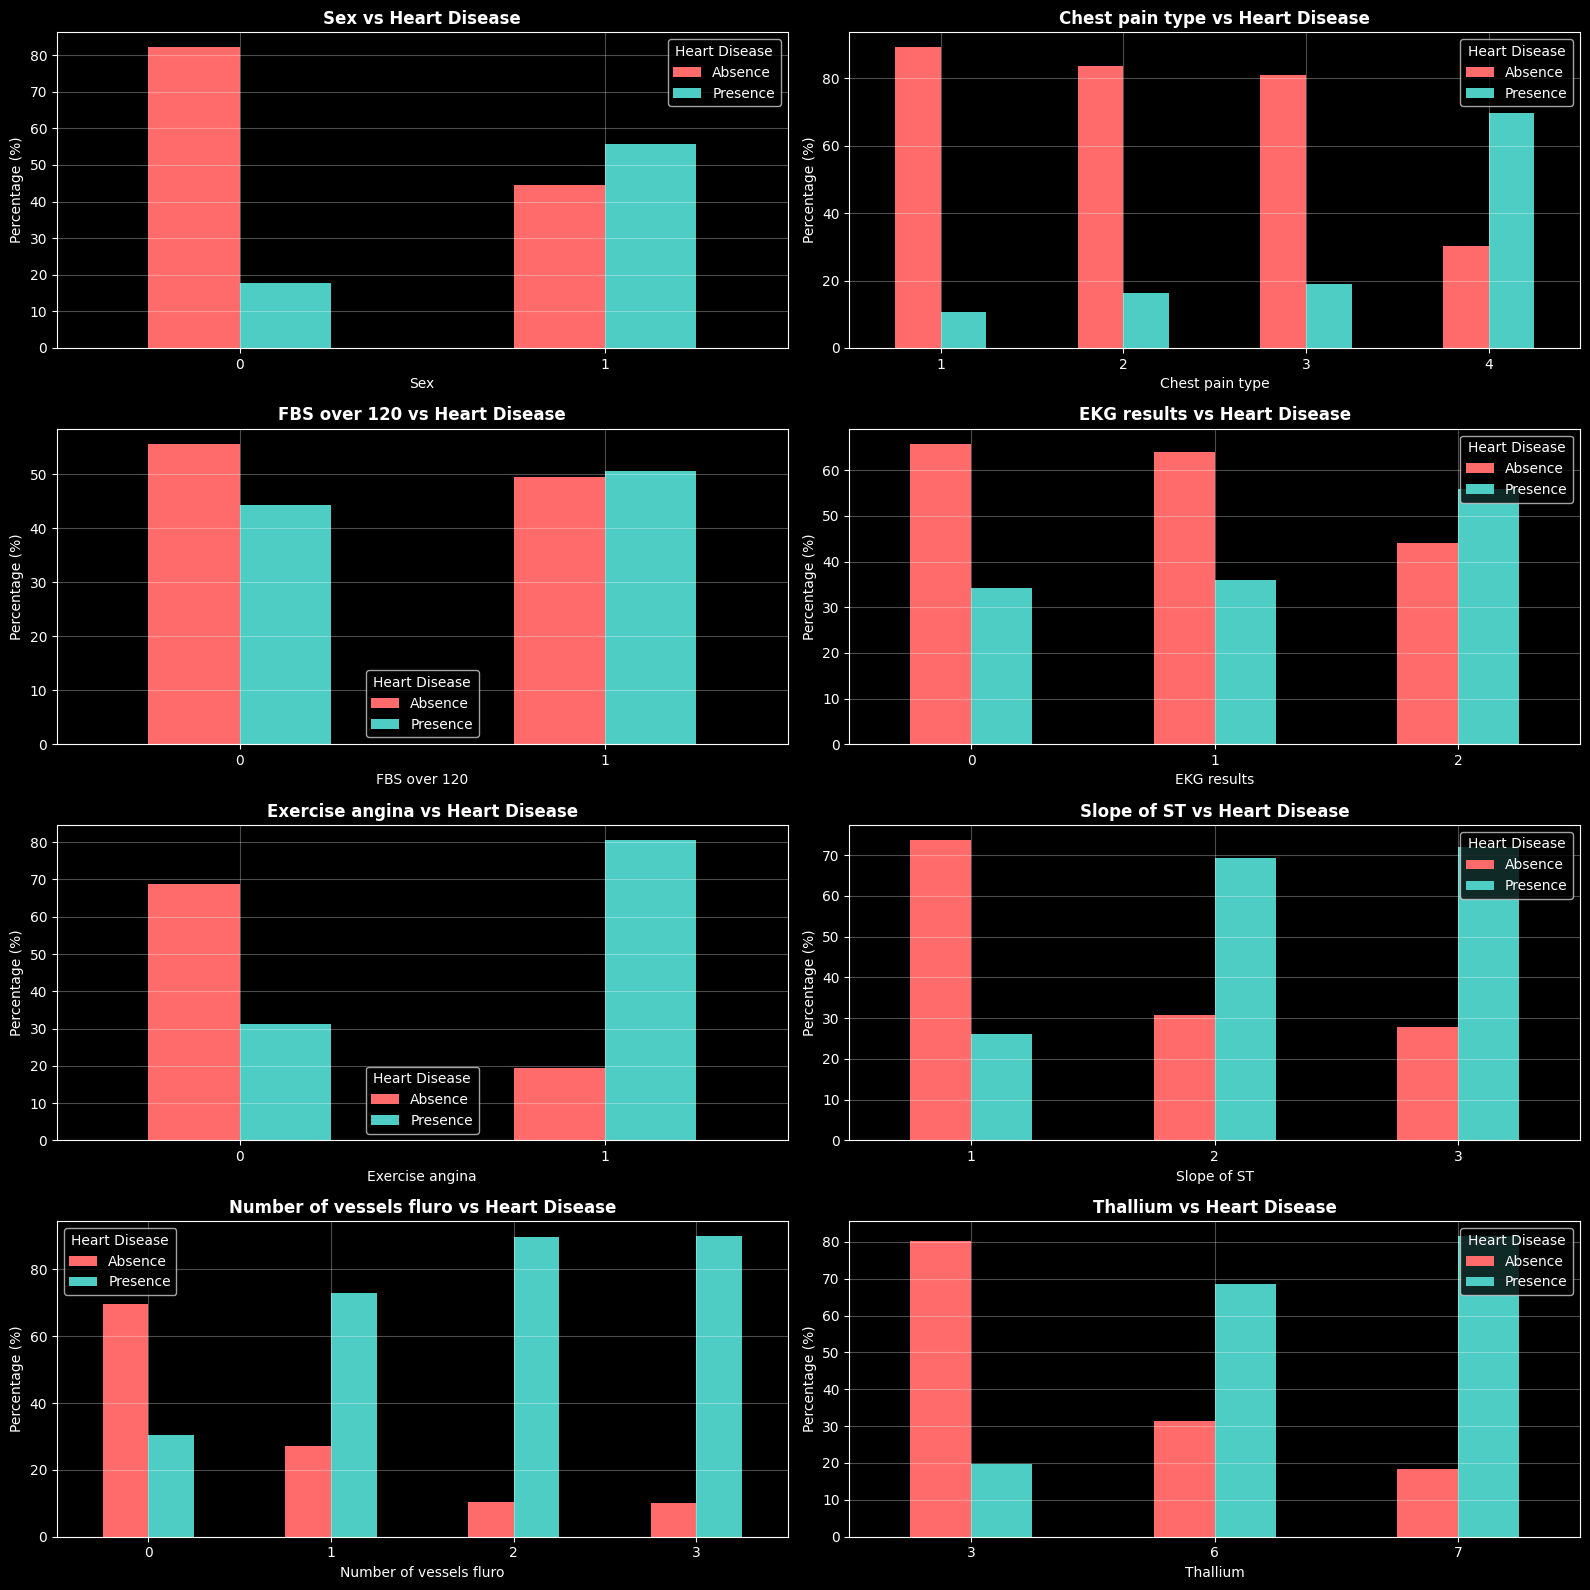

In [8]:
# Categorical features distribution

fig, axes = plt.subplots(4, 2, figsize = (16, 16))
axes = axes.ravel()

for idx, col in enumerate(categorical_features):
    cross_tab = pd.crosstab(
        train[col], 
        train["Heart Disease"], 
        normalize = "index"
    ) * 100
    
    cross_tab.plot(
        kind = "bar", 
        ax = axes[idx], 
        stacked = False, 
        color = ["#FF6B6B", "#4ECDC4"]
    )
    
    axes[idx].set_title(f"{col} vs Heart Disease", fontsize = 12, fontweight = "bold")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Percentage (%)")
    axes[idx].legend(title = "Heart Disease")
    axes[idx].grid(True, alpha = 0.3)
    plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation = 0)
    
plt.tight_layout()
plt.show()

## Chi-Square Tests

In [9]:
# Chi-square tests for categorical features

print("-" * 50)
print("Chi-square tests for categorical features")
print("-" * 50)

chi_results = []
for col in categorical_features:
    contingency_table = pd.crosstab(train[col], train ["target"])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    significance = "significant" if p_value < 0.5 else "not signifcant"
    chi_results.append({
        "Feature": col,
        "Chi2": chi2,
        "p-value": p_value,
        "Significance": significance
    })

    print(f"{col:30} | Chi2: {chi2: 8.2f} | p-value:.6f | {significance}")

chi_df = pd.DataFrame(chi_results).sort_values("p-value")
print("\n" + "-" * 50)
print("Features ranked by significance")
print("-" * 50)
print(chi_df.to_string(index = False))

--------------------------------------------------
Chi-square tests for categorical features
--------------------------------------------------
Sex                            | Chi2:  73878.22 | p-value:.6f | significant
Chest pain type                | Chi2:  173770.66 | p-value:.6f | significant
FBS over 120                   | Chi2:   709.74 | p-value:.6f | significant
EKG results                    | Chi2:  30248.42 | p-value:.6f | significant
Exercise angina                | Chi2:  123001.45 | p-value:.6f | significant
Slope of ST                    | Chi2:  116357.58 | p-value:.6f | significant
Number of vessels fluro        | Chi2:  135190.52 | p-value:.6f | significant
Thallium                       | Chi2:  231215.69 | p-value:.6f | significant

--------------------------------------------------
Features ranked by significance
--------------------------------------------------
                Feature          Chi2       p-value Significance
                    Sex  73878.22248

# Feature Engineering

In [11]:
# Feature Engineering
def ultra_feature_engineering(df, is_train = True):
    """
    Master feature engineering function - creates 100+ features
    """
    df = df.copy()
    
    # Polynomial Features
    from sklearn.preprocessing import PolynomialFeatures
    
    poly_cols = ["Age", "BP", "Cholesterol", "Max HR", "ST depression"]
    poly = PolynomialFeatures(degree = 2, include_bias = False, interaction_only = False)
    poly_array = poly.fit_transform(df[poly_cols])
    poly_names = poly.get_feature_names_out(poly_cols)
    
    for i, name in enumerate(poly_names):
        if name not in poly_cols:
            df[f"poly_{name}"] = poly_array[:, i]
    
    # Age-based features
    df["age_squared"] = df["Age"] ** 2
    df["age_cubed"] = df["Age"] ** 3
    df["age_sqrt"] = np.sqrt(df["Age"])
    df["age_log"] = np.log1p(df["Age"])
    df["age_decade"] = (df["Age"] // 10).astype(int)
    df["age_5year_bin"] = (df["Age"] // 5).astype(int)
    df["is_elderly"] = (df["Age"] > 65).astype(int)
    df["is_very_elderly"] = (df["Age"] > 75).astype(int)
    df["is_middle_aged"] = ((df["Age"] >= 45) & (df["Age"] <= 65)).astype(int)
    df["is_young"] = (df["Age"] < 45).astype(int)
    
    # Blood Pressure features
    df["bp_squared"] = df["BP"] ** 2
    df["bp_log"] = np.log1p(df["BP"])
    df["bp_risk_severe"] = (df["BP"] > 160).astype(int)
    df["bp_risk_moderate"] = (df["BP"] > 140).astype(int)
    df["bp_normal"] = (df["BP"] <= 120).astype(int)
    df["bp_elevated"] = ((df["BP"] > 120) & (df["BP"] <= 130)).astype(int)
    df["bp_stage1"] = ((df["BP"] > 130) & (df["BP"] <= 140)).astype(int)
    df["bp_stage2"] = (df["BP"] > 140).astype(int)
    
    # Cholesterol features
    df["chol_squared"] = df["Cholesterol"] ** 2
    df["chol_log"] = np.log1p(df["Cholesterol"])
    df["chol_very_high"] = (df["Cholesterol"] > 240).astype(int)
    df["chol_high"] = ((df["Cholesterol"] > 200) & (df["Cholesterol"] <= 240)).astype(int)
    df["chol_borderline"] = ((df["Cholesterol"] >= 180) & (df["Cholesterol"] <= 200)).astype(int)
    df["chol_normal"] = (df["Cholesterol"] < 180).astype(int)
    
    # Heart Rate features
    df["max_hr_squared"] = df["Max HR"] ** 2
    df["max_hr_log"] = np.log1p(df["Max HR"])
    df["target_hr"] = 220 - df["Age"]
    df["hr_deficit"] = df["target_hr"] - df["Max HR"]
    df["hr_percent_of_max"] = df["Max HR"] / df["target_hr"]
    df["hr_reserve"] = df["target_hr"] / (df["Max HR"] + 1)
    df["hr_very_low"] = (df["Max HR"] < 100).astype(int)
    df["hr_low"] = ((df["Max HR"] >= 100) & (df["Max HR"] < 120)).astype(int)
    df["hr_normal"] = ((df["Max HR"] >= 120) & (df["Max HR"] < 150)).astype(int)
    df["hr_high"] = (df["Max HR"] >= 150).astype(int)
    
    # ST Depression features
    df["st_squared"] = df["ST depression"] ** 2
    df["st_cubed"] = df["ST depression"] ** 3
    df["st_log"] = np.log1p(df["ST depression"])
    df["st_risk_critical"] = (df["ST depression"] > 2).astype(int)
    df["st_risk_severe"] = (df["ST depression"] > 1).astype(int)
    df["st_risk_moderate"] = ((df["ST depression"] > 0.5) & (df["ST depression"] <= 1)).astype(int)
    df["st_minimal"] = (df["ST depression"] <= 0.5).astype(int)
    
    # Two-way interactions
    df["age_bp"] = df["Age"] * df["BP"]
    df["age_chol"] = df["Age"] * df["Cholesterol"]
    df["age_hr"] = df["Age"] * df["Max HR"]
    df["age_st"] = df["Age"] * df["ST depression"]
    df["bp_chol"] = df["BP"] * df["Cholesterol"]
    df["bp_hr"] = df["BP"] * df["Max HR"]
    df["bp_st"] = df["BP"] * df["ST depression"]
    df["chol_hr"] = df["Cholesterol"] * df["Max HR"]
    df["chol_st"] = df["Cholesterol"] * df["ST depression"]
    df["hr_st"] = df["Max HR"] * df["ST depression"]
    
    # Three-way interactions
    df["age_bp_chol"] = df["Age"] * df["BP"] * df["Cholesterol"]
    df["age_hr_st"] = df["Age"] * df["Max HR"] * df["ST depression"]
    df["bp_chol_st"] = df["BP"] * df["Cholesterol"] * df["ST depression"]
    
    # Ratio features
    df["bp_per_age"] = df["BP"] / (df["Age"] + 1)
    df["chol_per_age"] = df["Cholesterol"] / (df["Age"] + 1)
    df["hr_per_age"] = df["Max HR"] / (df["Age"] + 1)
    df["st_per_age"] = df["ST depression"] / (df["Age"] + 1)
    df["st_per_hr"] = df["ST depression"] / (df["Max HR"] + 1)
    df["bp_to_chol_ratio"] = df["BP"] / (df["Cholesterol"] + 1)
    df["chol_to_bp_ratio"] = df["Cholesterol"] / (df["BP"] + 1)
    df["vessels_per_st"] = df["Number of vessels fluro"] / (df["ST depression"] + 0.1)
    
    # Categorical interactions
    df["sex_chest_pain"] = df["Sex"].astype(str) + "_" + df["Chest pain type"].astype(str)
    df["sex_angina"] = df["Sex"].astype(str) + "_" + df["Exercise angina"].astype(str)
    df["sex_slope"] = df["Sex"].astype(str) + "_" + df["Slope of ST"].astype(str)
    df["sex_ekg"] = df["Sex"].astype(str) + "_" + df["EKG results"].astype(str)
    df["chest_angina"] = df["Chest pain type"].astype(str) + "_" + df["Exercise angina"].astype(str)
    df["chest_slope"] = df["Chest pain type"].astype(str) + "_" + df["Slope of ST"].astype(str)
    df["angina_slope"] = df["Exercise angina"].astype(str) + "_" + df["Slope of ST"].astype(str)
    df["vessels_thal"] = df["Number of vessels fluro"].astype(str) + "_" + df["Thallium"].astype(str)
    df["sex_chest_angina"] = df["Sex"].astype(str) + "_" + df["Chest pain type"].astype(str) + "_" + df["Exercise angina"].astype(str)
    
    # Cardiovascular risk scores
    df["cv_risk_score"] = (
        (df["Age"] > 60).astype(int) * 3 +
        (df["BP"] > 140).astype(int) * 3 +
        (df["Cholesterol"] > 240).astype(int) * 3 +
        (df["FBS over 120"]).astype(int) * 2 +
        (df["Exercise angina"]).astype(int) * 4 +
        (df["ST depression"] > 1).astype(int) * 5 +
        (df["Number of vessels fluro"] > 0).astype(int) * 4 +
        (df["Max HR"] < 120).astype(int) * 2
    )
    
    df["weighted_risk"] = (
        df["ST depression"] * 0.3 +
        df["Number of vessels fluro"] * 0.25 +
        df["Exercise angina"] * 0.2 +
        (220 - df["Age"] - df["Max HR"]) * 0.15 +
        (df["BP"] / 200) * 0.05 +
        (df["Cholesterol"] / 400) * 0.05
    )
    
    df["risk_factor_count"] = (
        (df["bp_risk_moderate"]) +
        (df["chol_very_high"]) +
        (df["FBS over 120"]) +
        (df["Exercise angina"]) +
        (df["st_risk_severe"]) +
        (df["hr_very_low"]) +
        (df["Number of vessels fluro"] > 0).astype(int)
    )
    
    # Vessel & Thallium features
    df["vessel_severity"] = df["Number of vessels fluro"] * df["ST depression"]
    df["vessel_binary"] = (df["Number of vessels fluro"] > 0).astype(int)
    df["vessel_multiple"] = (df["Number of vessels fluro"] > 1).astype(int)
    df["vessel_severe"] = (df["Number of vessels fluro"] >= 3).astype(int)
    df["thal_reversible"] = (df["Thallium"] == 7).astype(int)
    df["thal_fixed"] = (df["Thallium"] == 6).astype(int)
    df["thal_normal"] = (df["Thallium"] == 3).astype(int)
    
    # Composite features
    df["metabolic_syndrome_score"] = (
        (df["BP"] > 130).astype(int) +
        (df["Cholesterol"] > 200).astype(int) +
        (df["FBS over 120"]).astype(int)
    )
    
    df["exercise_capacity"] = df["Max HR"] - df["ST depression"] * 10
    df["poor_exercise_tolerance"] = (
        (df["Max HR"] < 120).astype(int) & 
        (df["Exercise angina"] == 1).astype(int)
    )
    
    df["high_risk_combo"] = (
        (df["st_risk_critical"]) & 
        (df["vessel_multiple"]) & 
        (df["Exercise angina"] == 1)
    ).astype(int)
    
    df["very_high_risk"] = (df["cv_risk_score"] > 15).astype(int)
    
    # Normalized features
    df["bp_normalized"] = df["BP"] / 200
    df["chol_normalized"] = df["Cholesterol"] / 400
    df["hr_normalized"] = df["Max HR"] / 220
    df["st_normalized"] = df["ST depression"] / 5
    
    # Clustering features
    cluster_features = ["Age", "BP", "Cholesterol", "Max HR", "ST depression"]
    for n_clusters in [3, 5, 8]:
        kmeans = KMeans(n_clusters = n_clusters, random_state = 42, n_init = 10)
        df[f"cluster_{n_clusters}"] = kmeans.fit_predict(df[cluster_features])
    
    # Label encode categorical strings
    cat_cols_to_encode = [
        "sex_chest_pain", "sex_angina", "sex_slope", "sex_ekg",
        "chest_angina", "chest_slope", "angina_slope", "vessels_thal",
        "sex_chest_angina"
    ]
    
    for col in cat_cols_to_encode:
        df[col] = df[col].astype("category").cat.codes
    
    return df

# Apply feature engineering
print("Applying ultra feature engineering...")
train_fe = ultra_feature_engineering(train, is_train = True)
test_fe = ultra_feature_engineering(test, is_train = False)

print(f"Original features: {train.shape[1]}")
print(f"After engineering: {train_fe.shape[1]}")
print(f"New features created: {train_fe.shape[1] - train.shape[1]}")

Applying ultra feature engineering...
Original features: 16
After engineering: 124
New features created: 108


# Feature Selection

In [12]:
# Feature Selection
features_to_drop = ["id", "Heart Disease", "target"]
features_to_drop = [f for f in features_to_drop if f in train_fe.columns]

X = train_fe.drop(columns = features_to_drop)
y = train_fe["target"]
X_test = test_fe.drop(columns = ["id"])

# Ensure same columns
missing_cols = set(X.columns) - set(X_test.columns)
for col in missing_cols:
    X_test[col] = 0
X_test = X_test[X.columns]

print(f"Initial feature count: {X.shape[1]}")

# Remove low variance features
from sklearn.feature_selection import VarianceThreshold

selector_var = VarianceThreshold(threshold = 0.01)
selector_var.fit(X)
low_var_features = X.columns[~selector_var.get_support()].tolist()

print(f"\nRemoving {len(low_var_features)} low-variance features")

# Mutual Information
mi_scores = mutual_info_classif(X, y, random_state = 42, n_neighbors = 5)
mi_df = pd.DataFrame({
    "Feature": X.columns,
    "MI_Score": mi_scores
}).sort_values("MI_Score", ascending = False)

# F-Statistic
f_scores, f_pvals = f_classif(X, y)
f_df = pd.DataFrame({
    "Feature": X.columns,
    "F_Score": f_scores,
    "F_pval": f_pvals
}).sort_values("F_Score", ascending = False)

# Combine selection methods
top_mi = set(mi_df.nlargest(100, "MI_Score")["Feature"])
top_f = set(f_df[f_df["F_pval"] < 0.05].nlargest(100, "F_Score")["Feature"])
selected_features = list(top_mi.union(top_f))
selected_features = [f for f in selected_features if f not in low_var_features]

print(f"\nFeatures after selection: {len(selected_features)}")

# Update X and X_test
X = X[selected_features]
X_test = X_test[selected_features]

print(f"\nFinal feature set: {X.shape[1]} features")

print("\n" + "-" * 50)
print("Top 20 Features by Mutual Information")
print("-" * 50)
print(mi_df.head(20).to_string(index = False))

Initial feature count: 121

Removing 8 low-variance features

Features after selection: 99

Final feature set: 99 features

--------------------------------------------------
Top 20 Features by Mutual Information
--------------------------------------------------
          Feature  MI_Score
     vessels_thal  0.254800
 sex_chest_angina  0.245973
      thal_normal  0.236287
     chest_angina  0.219273
         Thallium  0.215103
      chest_slope  0.214502
    cv_risk_score  0.211194
  thal_reversible  0.208527
   sex_chest_pain  0.198347
exercise_capacity  0.175973
     angina_slope  0.174214
risk_factor_count  0.168488
  Chest pain type  0.167392
       sex_angina  0.158504
        sex_slope  0.155653
        st_per_hr  0.148656
       hr_reserve  0.142338
hr_percent_of_max  0.141380
       hr_per_age  0.139002
            hr_st  0.134970


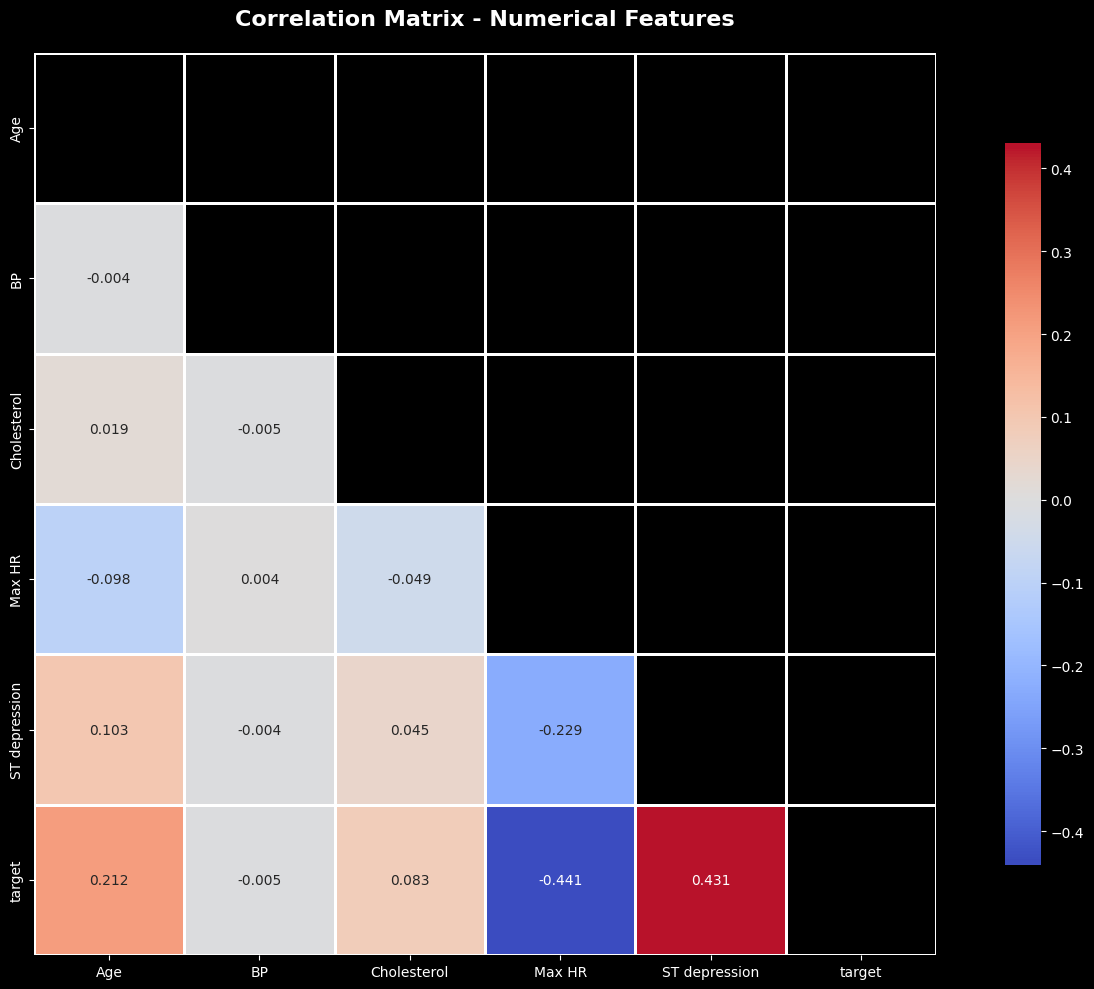


Feature Correlations with Target:
ST depression    0.430641
Age              0.212091
Cholesterol      0.082753
BP              -0.005181
Max HR          -0.440985
Name: target, dtype: float64
--------------------------------------------------
Advanced Correlation Analysis
--------------------------------------------------
                          Pearson  Pearson_p  Spearman  Spearman_p  Point_Biserial           PB_p   abs_max
Thallium                      NaN        NaN       NaN         NaN        0.605776   0.000000e+00  0.605776
Chest pain type               NaN        NaN       NaN         NaN        0.460684   0.000000e+00  0.460684
Exercise angina               NaN        NaN       NaN         NaN        0.441864   0.000000e+00  0.441864
Max HR                  -0.440985   0.000000 -0.441049    0.000000             NaN            NaN  0.441049
Number of vessels fluro       NaN        NaN       NaN         NaN        0.438604   0.000000e+00  0.438604
ST depression            0

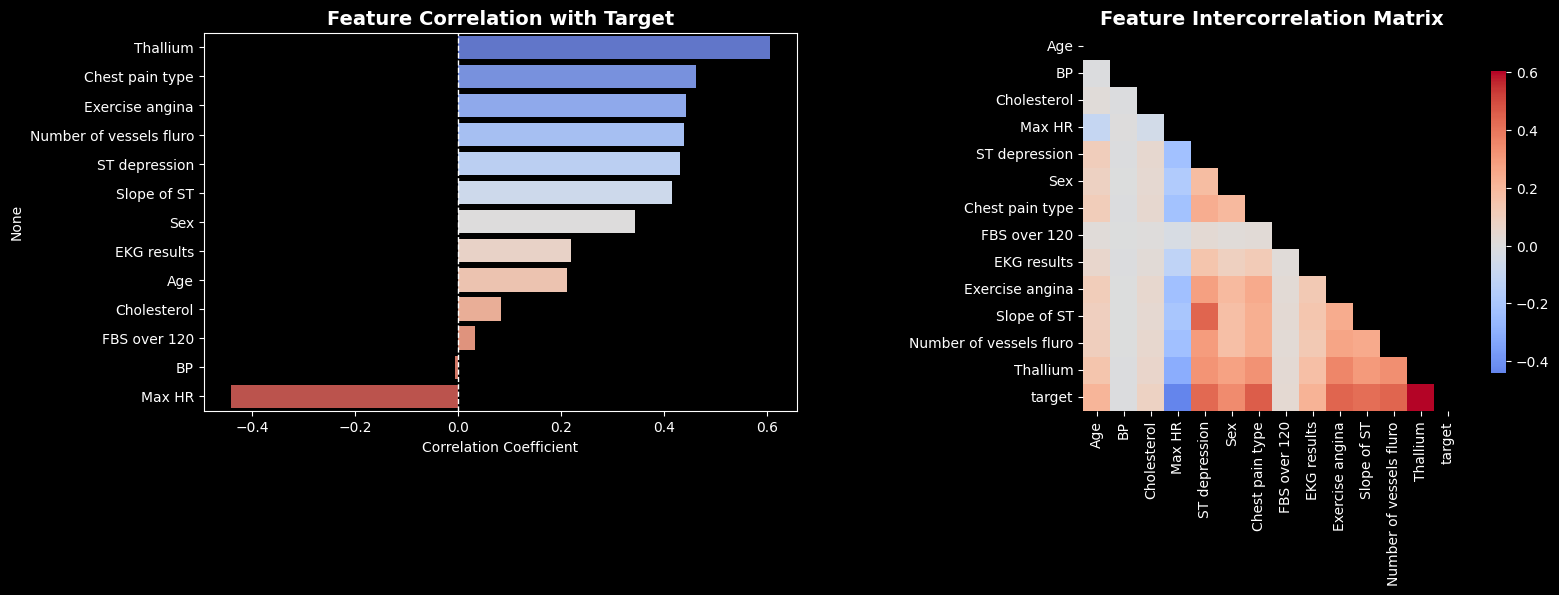


--------------------------------------------------
Highly Correlated Feature Pairs (|r| > 0.7)
--------------------------------------------------
No highly correlated pairs found
--------------------------------------------------
Mutual Information Scores
--------------------------------------------------
                Feature  MI_Score
               Thallium  0.235833
        Chest pain type  0.189003
                    Sex  0.132347
                 Max HR  0.128886
            Slope of ST  0.125048
        Exercise angina  0.123893
Number of vessels fluro  0.120622
          ST depression  0.107462
            EKG results  0.075849
                    Age  0.029904
            Cholesterol  0.011346
                     BP  0.010364
           FBS over 120  0.002341


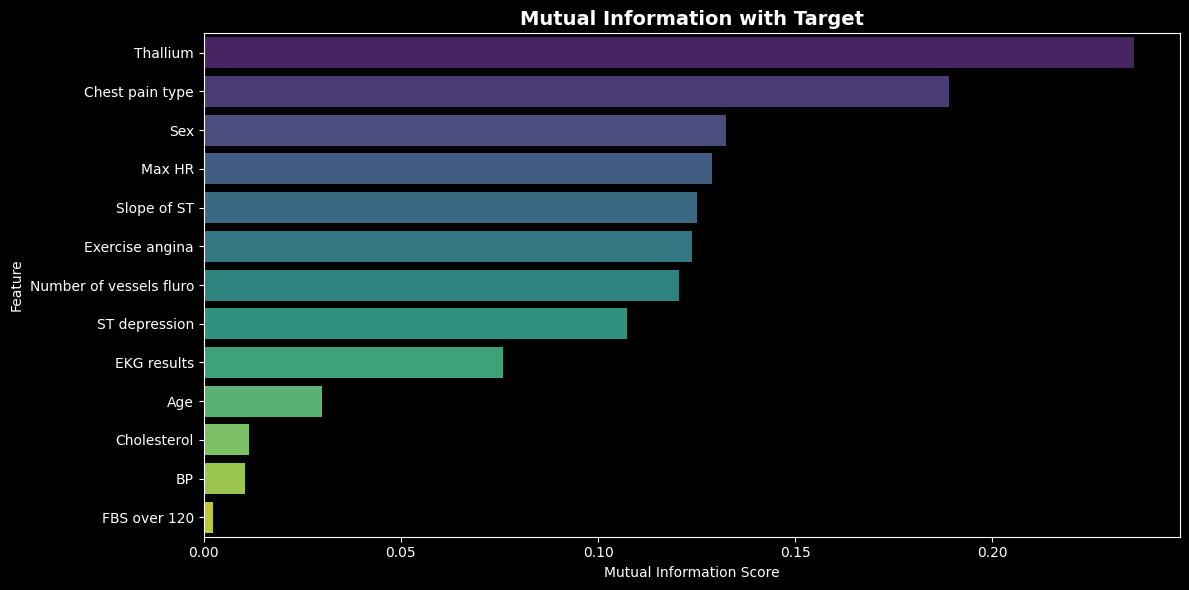

In [13]:
# Correlation Matrix
plt.figure(figsize = (14, 10))
correlation_matrix = train[numerical_features + ["target"]].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype = bool))

sns.heatmap(
    correlation_matrix, 
    mask = mask, 
    annot = True, 
    fmt = ".3f", 
    cmap = "coolwarm", 
    center = 0, 
    square = True, 
    linewidths = 1,
    cbar_kws = {"shrink": 0.8}
)
plt.title("Correlation Matrix - Numerical Features", fontsize = 16, fontweight = "bold", pad = 20)
plt.tight_layout()
plt.show()

# Feature correlations with target
target_corr = correlation_matrix["target"].drop("target").sort_values(ascending = False)
print("\nFeature Correlations with Target:")
print(target_corr)

# Advanced Correlation Analysis - Multiple Methods
from scipy.stats import pearsonr, spearmanr

print("-" * 50)
print("Advanced Correlation Analysis")
print("-" * 50)

correlations = {}

# Pearson correlation (linear relationships)
for col in numerical_features:
    pearson_corr, p_val = pearsonr(train[col], train["target"])
    correlations[col] = {
        "Pearson": pearson_corr,
        "Pearson_p": p_val
    }

# Spearman correlation (monotonic relationships)
for col in numerical_features:
    spearman_corr, p_val = spearmanr(train[col], train["target"])
    correlations[col]["Spearman"] = spearman_corr
    correlations[col]["Spearman_p"] = p_val

# Point-biserial for categorical
for col in categorical_features:
    pb_corr, p_val = pearsonr(train[col], train["target"])
    correlations[col] = {
        "Point_Biserial": pb_corr,
        "PB_p": p_val
    }

# Display results
corr_df = pd.DataFrame(correlations).T
corr_df["abs_max"] = corr_df[["Pearson", "Spearman", "Point_Biserial"]].abs().max(axis = 1)
corr_df = corr_df.sort_values("abs_max", ascending = False)

print(corr_df.to_string())
print("\n" + "-" * 50)

# Visualize
fig, axes = plt.subplots(1, 2, figsize = (16, 6))

# Correlation heatmap with target
all_features = numerical_features + categorical_features
corr_matrix = train[all_features + ["target"]].corr()
target_corr = corr_matrix["target"].drop("target").sort_values(ascending = False)

sns.barplot(x = target_corr.values, y = target_corr.index, ax = axes[0], palette = "coolwarm")
axes[0].set_title("Feature Correlation with Target", fontsize = 14, fontweight = "bold")
axes[0].set_xlabel("Correlation Coefficient")
axes[0].axvline(x = 0, color = "white", linestyle = "--", linewidth = 1)

# Feature intercorrelations
mask = np.triu(np.ones_like(corr_matrix, dtype = bool))
sns.heatmap(
    corr_matrix, 
    mask = mask, 
    annot = False, 
    cmap = "coolwarm", 
    center = 0, 
    square = True, 
    ax = axes[1], 
    cbar_kws = {"shrink": 0.8}
)
axes[1].set_title("Feature Intercorrelation Matrix", fontsize = 14, fontweight = "bold")

plt.tight_layout()
plt.show()

# Identify highly correlated feature pairs
print("\n" + "-" * 50)
print("Highly Correlated Feature Pairs (|r| > 0.7)")
print("-" * 50)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append({
                "Feature_1": corr_matrix.columns[i],
                "Feature_2": corr_matrix.columns[j],
                "Correlation": corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    print(pd.DataFrame(high_corr_pairs).to_string(index = False))
else:
    print("No highly correlated pairs found")

# Mutual Information - Detect non-linear relationships
mi_scores = mutual_info_classif(train[all_features], train["target"], random_state = 42)
mi_df = pd.DataFrame({
    "Feature": all_features,
    "MI_Score": mi_scores
}).sort_values("MI_Score", ascending = False)

print("-" * 50)
print("Mutual Information Scores")
print("-" * 50)
print(mi_df.to_string(index = False))

# Visualize
plt.figure(figsize = (12, 6))
sns.barplot(data = mi_df, x = "MI_Score", y = "Feature", palette = "viridis")
plt.title("Mutual Information with Target", fontsize = 14, fontweight = "bold")
plt.xlabel("Mutual Information Score")
plt.tight_layout()
plt.show()

# Hyperparameter

In [16]:
# Hyperparameter Optimization Setup
N_FOLDS = 10
RANDOM_STATE = 42
N_TRIALS = 100  # Increased from 50 for better optimization

skf = StratifiedKFold(n_splits = N_FOLDS, shuffle = True, random_state = RANDOM_STATE)

# Scale data
scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns = X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns = X_test.columns)

print(f"Cross-validation: {N_FOLDS} folds")
print(f"Optuna trials per model: {N_TRIALS}")
print("-" * 50)

Cross-validation: 10 folds
Optuna trials per model: 100
--------------------------------------------------


# XGBoost Optimization

In [17]:
# XGBoost Optimization - AGGRESSIVE
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 500, 3000),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_float("learning_rate", 0.0005, 0.3, log = True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 15),
        "gamma": trial.suggest_float("gamma", 0, 1.5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5.0),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 0.8, 1.5),
        "random_state": RANDOM_STATE,
        "eval_metric": "auc",
        "tree_method": "hist"
    }
    
    model = XGBClassifier(**params)
    scores = cross_val_score(model, X_scaled, y, cv = skf, scoring = "roc_auc", n_jobs = -1)
    return scores.mean()

print("Optimizing XGBoost...")
study_xgb = optuna.create_study(direction = "maximize", sampler = TPESampler(seed = RANDOM_STATE))
study_xgb.optimize(objective_xgb, n_trials = N_TRIALS, show_progress_bar = True)

print(f"\nBest XGBoost AUC: {study_xgb.best_value:.6f}")
print(f"Best params: {study_xgb.best_params}")

xgb_best_params = study_xgb.best_params

[I 2026-02-27 21:46:39,245] A new study created in memory with name: no-name-973e6a03-3655-49fd-ad69-95aa3f4c1030


Optimizing XGBoost...


  0%|          | 0/100 [00:00<?, ?it/s]

[W 2026-02-27 22:07:52,441] Trial 0 failed with parameters: {'n_estimators': 1436, 'max_depth': 15, 'learning_rate': 0.05402066039246068, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 3, 'gamma': 0.08712541825229919, 'reg_alpha': 4.330880728874676, 'reg_lambda': 3.005575058716044, 'scale_pos_weight': 1.295650804457232} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_55/1175315883.py", line 20, in objective_xgb
    scores = cross_val_score(model, X_scaled, y, cv = skf, scoring = "roc_auc", n_jobs = -1)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(

KeyboardInterrupt: 

# CatBoost Optimization

In [ ]:
# CatBoost Optimization
def objective_cat(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 500, 3000),
        "depth": trial.suggest_int("depth", 4, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.0005, 0.3, log = True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 15),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),
        "random_strength": trial.suggest_float("random_strength", 0, 10),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 0.8, 1.5),
        "random_seed": RANDOM_STATE,
        "verbose": 0,
        "eval_metric": "AUC"
    }
    
    model = CatBoostClassifier(**params)
    scores = cross_val_score(model, X_scaled, y, cv = skf, scoring = "roc_auc", n_jobs = -1)
    return scores.mean()

print("Optimizing CatBoost...")
study_cat = optuna.create_study(direction = "maximize", sampler = TPESampler(seed = RANDOM_STATE))
study_cat.optimize(objective_cat, n_trials = N_TRIALS, show_progress_bar = True)

print(f"\nBest CatBoost AUC: {study_cat.best_value:.6f}")
print(f"Best params: {study_cat.best_params}")

cat_best_params = study_cat.best_params

# LightGBM Optimization

In [ ]:
# LightGBM Optimization 
def objective_lgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 500, 3000),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_float("learning_rate", 0.0005, 0.3, log = True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 200),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5.0),
        "min_split_gain": trial.suggest_float("min_split_gain", 0, 1.0),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 0.8, 1.5),
        "random_state": RANDOM_STATE,
        "verbose": -1
    }
    
    model = LGBMClassifier(**params)
    scores = cross_val_score(model, X_scaled, y, cv = skf, scoring = "roc_auc", n_jobs = -1)
    return scores.mean()

print("Optimizing LightGBM...")
study_lgb = optuna.create_study(direction = "maximize", sampler = TPESampler(seed = RANDOM_STATE))
study_lgb.optimize(objective_lgb, n_trials = N_TRIALS, show_progress_bar = True)

print(f"\nBest LightGBM AUC: {study_lgb.best_value:.6f}")
print(f"Best params: {study_lgb.best_params}")

lgb_best_params = study_lgb.best_params

In [ ]:
# Train Models with Cross-Validation
from sklearn.model_selection import cross_val_predict

def train_model_cv(model, X, y, model_name):
    """Train model with CV and return OOF predictions"""
    oof_preds = np.zeros(len(X))
    scores = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_train_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]
        
        model.fit(X_train_fold, y_train_fold)
        y_pred_proba = model.predict_proba(X_val_fold)[:, 1]
        oof_preds[val_idx] = y_pred_proba
        
        fold_auc = roc_auc_score(y_val_fold, y_pred_proba)
        scores.append(fold_auc)
        print(f"  Fold {fold}: {fold_auc:.6f}")
    
    mean_auc = np.mean(scores)
    std_auc = np.std(scores)
    
    print(f"\n{model_name} CV AUC: {mean_auc:.6f} (+/- {std_auc:.6f})")
    print("-" * 50)
    
    return oof_preds, mean_auc

# Initialize models with best params
xgb_model = XGBClassifier(**xgb_best_params)
cat_model = CatBoostClassifier(**cat_best_params)
lgb_model = LGBMClassifier(**lgb_best_params)

# Train and get OOF predictions
print("-" * 50)
print("Training Optimized Models with Cross-Validation")
print("-" * 50)

xgb_oof, xgb_auc = train_model_cv(xgb_model, X_scaled, y, "XGBoost")
cat_oof, cat_auc = train_model_cv(cat_model, X_scaled, y, "CatBoost")
lgb_oof, lgb_auc = train_model_cv(lgb_model, X_scaled, y, "LightGBM")

# Train Random Forest and Extra Trees - LARGER
rf_model = RandomForestClassifier(
    n_estimators = 1500,
    max_depth = 15,
    min_samples_split = 4,
    min_samples_leaf = 1,
    max_features = "sqrt",
    class_weight = "balanced",
    random_state = RANDOM_STATE,
    n_jobs = -1
)
rf_oof, rf_auc = train_model_cv(rf_model, X_scaled, y, "Random Forest")

et_model = ExtraTreesClassifier(
    n_estimators = 1500,
    max_depth = 15,
    min_samples_split = 4,
    min_samples_leaf = 1,
    max_features = "sqrt",
    class_weight = "balanced",
    random_state = RANDOM_STATE,
    n_jobs = -1
)
et_oof, et_auc = train_model_cv(et_model, X_scaled, y, "Extra Trees")

# Train Neural Network

In [ ]:
# Train Neural Network
from tensorflow import keras
from tensorflow.keras import layers, callbacks

def create_nn():
    model = keras.Sequential([
        layers.Dense(512, activation = "relu", input_dim = X_scaled.shape[1]),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(256, activation = "relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation = "relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation = "relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(32, activation = "relu"),
        layers.Dropout(0.1),
        layers.Dense(1, activation = "sigmoid")
    ])
    
    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate = 0.0005),
        loss = "binary_crossentropy",
        metrics = [keras.metrics.AUC(name = "auc")]
    )
    return model

# Train NN with CV
nn_oof = np.zeros(len(X_scaled))
nn_scores = []

print("-" * 50)
print("Training Neural Network")
print("-" * 50)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y), 1):
    X_train_fold = X_scaled.iloc[train_idx]
    X_val_fold = X_scaled.iloc[val_idx]
    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]
    
    nn_model = create_nn()
    
    early_stop = callbacks.EarlyStopping(
        monitor = "val_auc",
        patience = 40,
        restore_best_weights = True,
        mode = "max"
    )
    
    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor = "val_auc",
        factor = 0.3,
        patience = 15,
        mode = "max",
        min_lr = 0.00001
    )
    
    nn_model.fit(
        X_train_fold, y_train_fold,
        validation_data = (X_val_fold, y_val_fold),
        epochs = 300,
        batch_size = 16,
        callbacks = [early_stop, reduce_lr],
        verbose = 0
    )
    
    y_pred = nn_model.predict(X_val_fold, verbose = 0).flatten()
    nn_oof[val_idx] = y_pred
    
    fold_auc = roc_auc_score(y_val_fold, y_pred)
    nn_scores.append(fold_auc)
    print(f"  Fold {fold}: {fold_auc:.6f}")

nn_auc = np.mean(nn_scores)
print(f"\nNeural Network CV AUC: {nn_auc:.6f} (+/- {np.std(nn_scores):.6f})")
print("-" * 50)

In [ ]:
# Create Meta-Features and Stack
meta_train = np.column_stack([xgb_oof, cat_oof, lgb_oof, rf_oof, et_oof, nn_oof])

print("-" * 50)
print("Training Meta-Model (Stacking)")
print("-" * 50)

# Try multiple meta-learners
from sklearn.linear_model import RidgeClassifier

meta_models = {
    "Logistic Regression": LogisticRegression(C = 0.05, random_state = RANDOM_STATE, max_iter = 2000),
    "Ridge Classifier": RidgeClassifier(alpha = 0.5, random_state = RANDOM_STATE),
    "Neural Net": MLPClassifier(
        hidden_layer_sizes = (200, 100, 50),
        activation = "relu",
        solver = "adam",
        alpha = 0.001,
        learning_rate = "adaptive",
        max_iter = 2000,
        random_state = RANDOM_STATE
    ),
    "XGBoost Meta": XGBClassifier(
        n_estimators = 200,
        max_depth = 4,
        learning_rate = 0.05,
        random_state = RANDOM_STATE
    ),
    "LightGBM Meta": LGBMClassifier(
        n_estimators = 200,
        max_depth = 4,
        learning_rate = 0.05,
        random_state = RANDOM_STATE,
        verbose = -1
    )
}

meta_results = {}
for name, meta_model in meta_models.items():
    scores = cross_val_score(meta_model, meta_train, y, cv = 7, scoring = "roc_auc")
    meta_results[name] = scores.mean()
    print(f"{name:25} Meta AUC: {scores.mean():.6f} (+/- {scores.std():.6f})")

# Select best meta-model
best_meta_name = max(meta_results, key = meta_results.get)
best_meta_model = meta_models[best_meta_name]

print(f"\nBest Meta-Model: {best_meta_name} with AUC: {meta_results[best_meta_name]:.6f}")

# Train final meta-model
best_meta_model.fit(meta_train, y)

# Get OOF predictions from meta-model
stack_oof = cross_val_predict(best_meta_model, meta_train, y, cv = 7, method = "predict_proba")[:, 1]
stack_auc = roc_auc_score(y, stack_oof)

print(f"Stacking Ensemble OOF AUC: {stack_auc:.6f}")
print("-" * 50)

In [20]:
# Weighted Ensemble
weights = {
    "xgb": xgb_auc,
    "cat": cat_auc,
    "lgb": lgb_auc,
    "rf": rf_auc,
    "et": et_auc,
    "nn": nn_auc
}

# Normalize weights
total_weight = sum(weights.values())
weights = {k: v / total_weight for k, v in weights.items()}

print("-" * 50)
print("Weighted Ensemble")
print("-" * 50)
print("Normalized Weights:")
for model, weight in sorted(weights.items(), key = lambda x: x[1], reverse = True):
    print(f"  {model.upper():5} : {weight:.4f} ({weight * 100:.2f}%)")

# Weighted ensemble OOF
weighted_oof = (
    weights["xgb"] * xgb_oof +
    weights["cat"] * cat_oof +
    weights["lgb"] * lgb_oof +
    weights["rf"] * rf_oof +
    weights["et"] * et_oof +
    weights["nn"] * nn_oof
)

weighted_auc = roc_auc_score(y, weighted_oof)
print(f"\nWeighted Ensemble OOF AUC: {weighted_auc:.6f}")
print("-" * 50)

# POWER WEIGHTED ENSEMBLE - Square the weights to amplify best models
print("\nPower Weighted Ensemble:")
power_weights = {k: v ** 1.5 for k, v in weights.items()}
total_power_weight = sum(power_weights.values())
power_weights = {k: v / total_power_weight for k, v in power_weights.items()}

print("Power Weights:")
for model, weight in sorted(power_weights.items(), key = lambda x: x[1], reverse = True):
    print(f"  {model.upper():5} : {weight:.4f} ({weight * 100:.2f}%)")

power_weighted_oof = (
    power_weights["xgb"] * xgb_oof +
    power_weights["cat"] * cat_oof +
    power_weights["lgb"] * lgb_oof +
    power_weights["rf"] * rf_oof +
    power_weights["et"] * et_oof +
    power_weights["nn"] * nn_oof
)

power_weighted_auc = roc_auc_score(y, power_weighted_oof)
print(f"Power Weighted Ensemble OOF AUC: {power_weighted_auc:.6f}")
print("-" * 50)

NameError: name 'xgb_auc' is not defined

In [19]:
# Final Ensemble Comparison
print("\n" + "-" * 50)
print("Ensemble Comparison")
print("-" * 50)

ensemble_results = {
    "Weighted Average": weighted_auc,
    "Power Weighted": power_weighted_auc,
    "Stacking": stack_auc,
    "Best Single Model": max(xgb_auc, cat_auc, lgb_auc, rf_auc, et_auc, nn_auc)
}

for name, auc in sorted(ensemble_results.items(), key = lambda x: x[1], reverse = True):
    print(f"{name:25} : {auc:.6f}")

# Choose best approach
best_ensemble_name = max(ensemble_results, key = ensemble_results.get)
best_ensemble_auc = ensemble_results[best_ensemble_name]

if best_ensemble_name == "Stacking":
    final_oof = stack_oof
    use_stacking = True
    use_power = False
elif best_ensemble_name == "Power Weighted":
    final_oof = power_weighted_oof
    use_stacking = False
    use_power = True
else:
    final_oof = weighted_oof
    use_stacking = False
    use_power = False

print(f"\nUsing {best_ensemble_name} ensemble (AUC: {best_ensemble_auc:.6f})")
print("-" * 50)


--------------------------------------------------
Ensemble Comparison
--------------------------------------------------


NameError: name 'weighted_auc' is not defined

In [ ]:
# Threshold Optimization
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y, final_oof)

# Maximize Youden's J statistic
youdens_j = tpr - fpr
optimal_idx = np.argmax(youdens_j)
optimal_threshold = thresholds[optimal_idx]

print("-" * 50)
print("Threshold Optimization")
print("-" * 50)
print(f"Default threshold: 0.5000")
print(f"Optimal threshold (Youden's J): {optimal_threshold:.4f}")
print(f"  - Sensitivity (TPR): {tpr[optimal_idx]:.4f}")
print(f"  - Specificity (1-FPR): {1 - fpr[optimal_idx]:.4f}")

# Visualize ROC curve
plt.figure(figsize = (10, 8))
plt.plot(fpr, tpr, linewidth = 2, label = f"ROC Curve (AUC = {roc_auc_score(y, final_oof):.6f})")
plt.plot([0, 1], [0, 1], "k--", linewidth = 1, label = "Random Classifier")
plt.scatter(
    fpr[optimal_idx], 
    tpr[optimal_idx], 
    s = 200, 
    c = "red", 
    marker = "*", 
    label = f"Optimal Threshold = {optimal_threshold:.3f}", 
    zorder = 5
)
plt.xlabel("False Positive Rate", fontsize = 12)
plt.ylabel("True Positive Rate", fontsize = 12)
plt.title("ROC Curve - Final Ensemble", fontsize = 14, fontweight = "bold")
plt.legend(fontsize = 10)
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

print("-" * 50)

In [ ]:
# Train Final Models on Full Data
print("-" * 50)
print("Training Final Models on Full Dataset")
print("-" * 50)

# Train all models on full training data
xgb_final = XGBClassifier(**xgb_best_params)
cat_final = CatBoostClassifier(**cat_best_params)
lgb_final = LGBMClassifier(**lgb_best_params)
rf_final = RandomForestClassifier(**rf_model.get_params())
et_final = ExtraTreesClassifier(**et_model.get_params())

xgb_final.fit(X_scaled, y)
cat_final.fit(X_scaled, y)
lgb_final.fit(X_scaled, y)
rf_final.fit(X_scaled, y)
et_final.fit(X_scaled, y)

print("Gradient boosting models trained")

# Train final neural network
nn_final = create_nn()
early_stop = callbacks.EarlyStopping(monitor = "loss", patience = 30, restore_best_weights = True)
nn_final.fit(X_scaled, y, epochs = 300, batch_size = 16, callbacks = [early_stop], verbose = 0)

print("Neural network trained")

# Generate test predictions for each model
xgb_test = xgb_final.predict_proba(X_test_scaled)[:, 1]
cat_test = cat_final.predict_proba(X_test_scaled)[:, 1]
lgb_test = lgb_final.predict_proba(X_test_scaled)[:, 1]
rf_test = rf_final.predict_proba(X_test_scaled)[:, 1]
et_test = et_final.predict_proba(X_test_scaled)[:, 1]
nn_test = nn_final.predict(X_test_scaled, verbose = 0).flatten()

print("Test predictions generated")
print("-" * 50)

# Generate Final Predictions

In [18]:
# Generate Final Predictions
if use_stacking:
    # Create meta-features for test set
    meta_test = np.column_stack([xgb_test, cat_test, lgb_test, rf_test, et_test, nn_test])
    final_test_pred = best_meta_model.predict_proba(meta_test)[:, 1]
    print("Using Stacking ensemble for final predictions")
elif use_power:
    # Power weighted average
    final_test_pred = (
        power_weights["xgb"] * xgb_test +
        power_weights["cat"] * cat_test +
        power_weights["lgb"] * lgb_test +
        power_weights["rf"] * rf_test +
        power_weights["et"] * et_test +
        power_weights["nn"] * nn_test
    )
    print("Using Power Weighted ensemble for final predictions")
else:
    # Regular weighted average
    final_test_pred = (
        weights["xgb"] * xgb_test +
        weights["cat"] * cat_test +
        weights["lgb"] * lgb_test +
        weights["rf"] * rf_test +
        weights["et"] * et_test +
        weights["nn"] * nn_test
    )
    print("Using Weighted ensemble for final predictions")

# Convert to binary using optimal threshold
final_test_binary = (final_test_pred > optimal_threshold).astype(int)

print(f"\nTest Prediction Distribution:")
print(f"  Class 0 (Absence):  {(final_test_binary == 0).sum()} ({(final_test_binary == 0).sum() / len(final_test_binary) * 100:.2f}%)")
print(f"  Class 1 (Presence): {(final_test_binary == 1).sum()} ({(final_test_binary == 1).sum() / len(final_test_binary) * 100:.2f}%)")

NameError: name 'use_stacking' is not defined

In [ ]:
# Create Submission
submission = pd.DataFrame({
    "id": test["id"],
    "Heart Disease": final_test_binary
})

# Save
submission.to_csv("submission.csv", index = False)

print("-" * 50)
print("Submission File Created")
print("-" * 50)
print(f"Shape: {submission.shape}")
print(f"\nFirst 10 rows:")
print(submission.head(10))
print(f"\nPrediction distribution:")
print(submission["Heart Disease"].value_counts())
print("\n" + "-" * 50)